# Goal: Predict Mortality

* The task is a ML supervised, binary classification of mortality
* The synthetic data is  from http://hdx.mitre.org/downloads/syntheticmass/100k_synthea_covid19_csv.zip 
* The data is unbalanced as mortality = 19.5% and the majority voting / guess accuracy = 80.5%  
* The best performance metric to monitor is F1 score with accuracy, precision, recall and AUC


## Problems 

* Original data is in 16 tables in a relational format – needs to be flattened
* While there are a several numerical features (age, longitude, latitude, etc.)…
* Data is mostly categorical and highly dimensional (many meds, conditions, observations, etc.)
* One Hot Encoding the categorical features will create a sparse matrix (aka curse of dimensionality)

## Plan
* Categorical concepts embedding / vectorization instead of OHE
* Use these vectors as features (aka representational learning) together with the other numerical features
* Create new features as the number of all interactions between patient – system (number of meds, labs, care-plans, providers, etc.)
* ALL the above categories of features - at once

## Results 
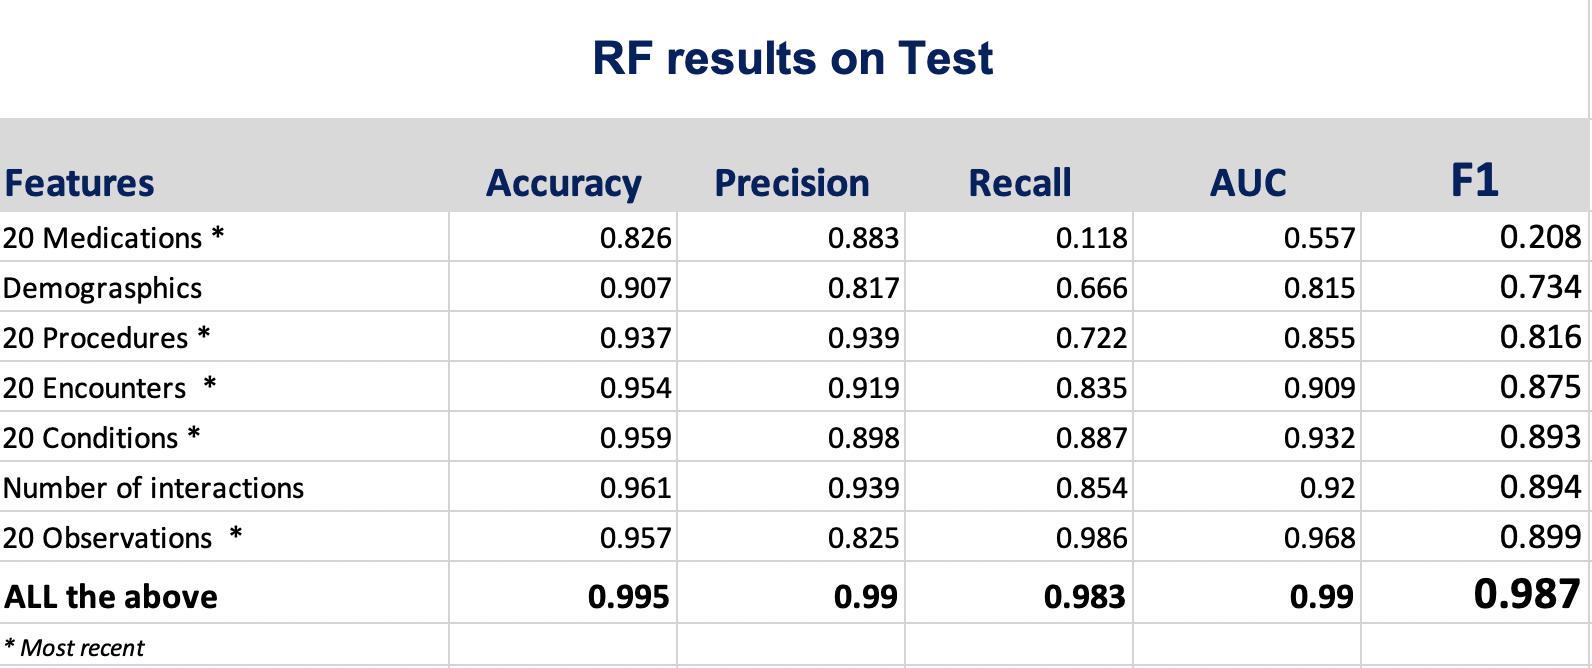

### Future
* Keras double input NN (simple NN on numericals and RNN on emebeddings, concatenated before the last sigmoid layer)

In [ ]:
import numpy as np  
import pandas as pd  
import os
from typing import Tuple
import pickle
import seaborn as sns
import time
from collections import Counter, OrderedDict

import gc
gc.enable()

import matplotlib.pyplot as plt
import plotly.io as plt_io
import plotly.graph_objects as go
from matplotlib.pyplot import figure
%matplotlib inline
from mpl_toolkits.basemap import Basemap

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score, auc

from sklearn import model_selection, preprocessing
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV,KFold, cross_val_predict, StratifiedKFold, train_test_split, learning_curve, ShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC 
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, ShuffleSplit
from sklearn.model_selection import cross_val_predict

import tensorflow as tf
from keras import models, regularizers, layers, optimizers, losses, metrics
from keras.models import Sequential
from keras.layers import Dense, Embedding
from keras.utils import np_utils
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

pd.options.display.max_columns =999
pd.options.display.max_rows = 999

from pdpbox import pdp, get_dataset, info_plots
import shap 
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
listFiles = os.listdir('/kaggle/input/syntheacovid100k/100k_synthea_covid19_csv')
listFiles

In [ ]:
# Function for a nice CM

def plot_confusion_matrix(cm,target_names,title='Confusion matrix',cmap=None,
                          normalize=False):
    import itertools
    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    
    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")


    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label\naccuracy={:0.4f}; misclass={:0.4f}'.format(accuracy, misclass))
    plt.show()

# Data

In [ ]:
patients = pd.read_csv('/kaggle/input/syntheacovid100k/100k_synthea_covid19_csv/patients.csv')
print(patients.shape)
patients.sample()

In [ ]:
len(patients.Id.unique())

In [ ]:
# Mortality 

patients.DEATHDATE.value_counts().sum() / len(patients.Id.unique())

In [ ]:
RawData4ML = patients.copy()
RawData4ML = RawData4ML[['Id', 'BIRTHDATE', 'DEATHDATE','MARITAL', 'RACE', 'ETHNICITY',
       'GENDER','LAT', 'LON', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE']]
RawData4ML.sample()

In [ ]:
%%time

# assign dataset names
list_of_names = ['observations.csv',
 'careplans.csv',
 'conditions.csv',
 'encounters.csv',
 'procedures.csv',
 'allergies.csv',
 'medications.csv',
 'payers.csv',
 'organizations.csv',
 'imaging_studies.csv',
 'supplies.csv',
 'patients.csv',
 'devices.csv',
 'payer_transitions.csv',
 'providers.csv',
 'immunizations.csv']

# create empty list
dataframes_list = []
  
for name in list_of_names:
    name = name[:-4]
    print(name, end=' ')
    name = pd.read_csv("/kaggle/input/syntheacovid100k/100k_synthea_covid19_csv/"+str(name)+".csv")
    dataframes_list.append(name)
    print(name.shape)

In [ ]:
observations = dataframes_list[0]
careplans = dataframes_list[1]
conditions = dataframes_list[2]
encounters = dataframes_list[3]
procedures = dataframes_list[4]
allergies = dataframes_list[5]
medications = dataframes_list[6]
payers = dataframes_list[7]
organizations = dataframes_list[8]
imaging_studies = dataframes_list[9]
supplies = dataframes_list[10]
patients = dataframes_list[11]
devices = dataframes_list[12]
payer_transitions = dataframes_list[13]
providers = dataframes_list[14]
immunizations = dataframes_list[15]

print(observations.shape)
print(careplans.shape)
print(conditions.shape)
print(encounters.shape)
print(procedures.shape)
print(allergies.shape)
print(medications.shape)
print(payers.shape)
print(organizations.shape)
print(imaging_studies.shape)
print(supplies.shape)
print(patients.shape)
print(devices.shape)
print(payer_transitions.shape)
print(providers.shape)
print(immunizations.shape)


In [ ]:
del dataframes_list
gc.collect()

# Prevent data leakage ... Feature contains word DEATH

In [ ]:
# observations has 18,134 Cause of Death
print(observations.shape)
observations = observations.loc[~observations['DESCRIPTION'].str.contains("death", case=False)]
print(observations.shape)

# encounters 18,134 Death certificate
print(encounters.shape)
encounters = encounters.loc[~encounters['DESCRIPTION'].str.contains("death", case=False)]
print(encounters.shape)

# conditions , procedures ...No label leakage
print(conditions.loc[conditions['DESCRIPTION'].str.contains("death", case=False)].shape)
procedures.loc[procedures['DESCRIPTION'].str.contains("death", case=False)].shape

# Count number of interactions between patient and system

In [ ]:
%%time

conditionsCount = conditions.groupby('PATIENT').size().reset_index(name='NumConditions')
conditionsCount.columns = ['Id','NumConditions']

proceduresCount = procedures.groupby('PATIENT').size().reset_index(name='NumProcedures')
proceduresCount.columns = ['Id','NumProcedures']

medicationsCount = medications.groupby('PATIENT').size().reset_index(name='NumMedications')
medicationsCount.columns = ['Id','NumMedications']

observationsCount = observations.groupby('PATIENT').size().reset_index(name='NumObservations')
observationsCount.columns = ['Id','NumObservations']

encountersCount = encounters.groupby('PATIENT').size().reset_index(name='NumEncounters')
encountersCount.columns = ['Id','NumEncounters']

imaging_studiesCount = imaging_studies.groupby('PATIENT').size().reset_index(name='NumImages')
imaging_studiesCount.columns = ['Id','NumImages']

careplansCount = careplans.groupby('PATIENT').size().reset_index(name='NumCareplans')
careplansCount.columns = ['Id','NumCareplans']

allergiesCount = allergies.groupby('PATIENT').size().reset_index(name='NumAllergies')
allergiesCount.columns = ['Id','NumAllergies']

payersCount = payers.groupby('Id').size().reset_index(name='NumPayers')
payersCount.columns = ['Id','NumPayers']

organizationsCount = organizations.groupby('Id').size().reset_index(name='NumOrganizations')
organizationsCount.columns = ['Id','NumOrganizations']

suppliesCount = supplies.groupby('PATIENT').size().reset_index(name='NumSupplies')
suppliesCount.columns = ['Id','NumSupplies']

devicesCount = devices.groupby('PATIENT').size().reset_index(name='NumDevices')
devicesCount.columns = ['Id','NumDevices']

payer_transitionsCount = payer_transitions.groupby('PATIENT').size().reset_index(name='NumPayer_transitions')
payer_transitionsCount.columns = ['Id','NumPayer_transitions']

providersCount = providers.groupby('Id').size().reset_index(name='NumProviders')
providersCount.columns = ['Id','NumProviders']

immunizationsCount = immunizations.groupby('PATIENT').size().reset_index(name='NumImmunizations')
immunizationsCount.columns = ['Id','NumImmunizations']

RawData4ML = RawData4ML.merge(immunizationsCount, how='left', on='Id')
RawData4ML = RawData4ML.merge(providersCount, how='left', on='Id')
RawData4ML = RawData4ML.merge(payer_transitionsCount, how='left', on='Id')
RawData4ML = RawData4ML.merge(devicesCount, how='left', on='Id')
RawData4ML = RawData4ML.merge(suppliesCount, how='left', on='Id')
RawData4ML = RawData4ML.merge(organizationsCount, how='left', on='Id')
RawData4ML = RawData4ML.merge(payersCount, how='left', on='Id')
RawData4ML = RawData4ML.merge(allergiesCount, how='left', on='Id')
RawData4ML = RawData4ML.merge(careplansCount, how='left', on='Id')
RawData4ML = RawData4ML.merge(imaging_studiesCount, how='left', on='Id')
RawData4ML = RawData4ML.merge(encountersCount, how='left', on='Id')
RawData4ML = RawData4ML.merge(observationsCount, how='left', on='Id')
RawData4ML = RawData4ML.merge(medicationsCount, how='left', on='Id')
RawData4ML = RawData4ML.merge(proceduresCount, how='left', on='Id')
RawData4ML = RawData4ML.merge(conditionsCount, how='left', on='Id')

In [ ]:
# Mortality

RawData4ML['Dead'] = 0
RawData4ML['Dead'] = ~RawData4ML.DEATHDATE.isnull()
RawData4ML.drop('DEATHDATE', axis=1, inplace=True)
RawData4ML.Dead.value_counts(normalize=True)

In [ ]:
# Categorical data

print(RawData4ML.shape)
cols4OHE = ['MARITAL', 'RACE', 'ETHNICITY']

RawData4ML = pd.get_dummies(RawData4ML, columns = cols4OHE)
print(RawData4ML.shape)
RawData4ML.isnull().sum()

In [ ]:
# Gender and fillna

RawData4ML['GENDER']=RawData4ML['GENDER'].apply(lambda x: 1 if x =='M'  else 0)
RawData4ML.fillna(value=0, inplace=True)
RawData4ML.isnull().sum()

In [ ]:
# Age

RawData4ML['BIRTHDATE'] = pd.to_datetime(RawData4ML['BIRTHDATE'])
RawData4ML['BIRTHDATE']

now = pd.to_datetime('now')

RawData4ML['Age'] = (now - RawData4ML['BIRTHDATE']).astype('<m8[Y]') 
RawData4ML.drop('BIRTHDATE', axis=1, inplace=True)
RawData4ML.head(1)

#Prep ONLY num of interactions - REMOVE demographics

RawData4ML = RawData4ML[['Id', 'NumImmunizations', 'NumProviders',
       'NumPayer_transitions', 'NumDevices', 'NumSupplies', 'NumOrganizations',
       'NumPayers', 'NumAllergies', 'NumCareplans', 'NumImages',
       'NumEncounters', 'NumObservations', 'NumMedications', 'NumProcedures',
       'NumConditions', 'Dead']]


In [ ]:
# Separate X,y for normalizing only X

# RawData4ML = RawData4ML.sample(frac=1, random_state=42) # shuffles df

y = RawData4ML.Dead.values
print(y.shape)
#X = RawData4ML.drop(['Dead','Id', 'Conditions'], axis=1)
X = RawData4ML.drop(['Dead','Id'], axis=1)
print(X.shape)

# Normalize X

x = X.values #returns a numpy array
scaler = preprocessing.StandardScaler()
x_scaled = scaler.fit_transform(x)
X = pd.DataFrame(x_scaled, columns=X.columns)
print(X.shape)
X.tail(1)

# Prep concepts for embedding

* Arrange descending order - pick only last, 20 most recent
* Concatenate words into concepts - chronic sinusitis = chronic_sinusitis
* Remove duplicates
* Tokenize
* Vectorize into one dimension
* Add the vectors as features

In [ ]:
numFeat = 20

### Conditions

In [ ]:
# Concepts are separated by comma ,

conditions.sort_values(by =['PATIENT', 'START'],ascending=False, inplace=True)
conditions.DESCRIPTION = conditions.DESCRIPTION.str.lower()
conditions.DESCRIPTION = conditions.DESCRIPTION.str.replace('(', '')
conditions.DESCRIPTION = conditions.DESCRIPTION.str.replace(')', '')
conditions.DESCRIPTION = conditions.DESCRIPTION.replace(' ', '_', regex=True)
conditionsGr = conditions.groupby('PATIENT')['DESCRIPTION'].apply(lambda x: ' '.join(x)).reset_index()
conditionsGr.columns = ['Id','Conditions']
conditionsGr.head()
RawData4ML = RawData4ML.merge(conditionsGr, how='left', on='Id')

# Remove duplicates

RawData4ML['Conditions'] = (RawData4ML['Conditions'].astype(str).str.split()
                              .apply(lambda x: OrderedDict.fromkeys(x).keys())
                              .str.join(' '))

RawData4ML.head(1)

In [ ]:
texts = RawData4ML['Conditions'].astype(str).tolist()
print(len(texts))
# Number of concepts: max, mean, std

RawData4ML.Conditions.str.split().str.len().max(),RawData4ML.Conditions.str.split().str.len().mean(), RawData4ML.Conditions.str.split().str.len().std()

In [ ]:
# Tokenize from words to integers (sequences) ... removed underscore _ the dot . and minus - from the filters

maxlen = numFeat # cut off after this number of words in a text...
max_words = 200 # considers only the top number of words
max_features = max_words

tokenizer = Tokenizer(num_words=max_words, 
                     filters='!"#$%&()*+,/:;<=>?@[\\]^`{|}~\t\n',)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

data = pad_sequences(sequences, maxlen=maxlen, padding='post', truncating='post', value=0.0)

print(data.shape)

In [ ]:
rowNum = 123

print(texts[rowNum])
print(sequences[rowNum])
print(data[rowNum])

In [ ]:
# Embedding model: from integers to floating point vectors

Emodel = Sequential()
Emodel.add(Embedding(max_features, 1, input_length=maxlen))

output_array = Emodel.predict(data)
output_array.shape

In [ ]:
# The DICTIONARY between vectors and their integers is in the weights of the Embedding layer

embeddings = Emodel.layers[0].get_weights()[0]
embeddings.shape

In [ ]:
# Back from vectors to one review - whole text
# Create a new list fromVsequences of integers from the VECTORIZED embeddings
# NOTE only ONE sample / review - rowNum  - is translated at a time from vectors to words

rowNum=0

reverse_word_index = dict(
[(value, key) for (key, value) in word_index.items()])


fromVsequences = []

for wordNum in range(len(output_array[rowNum])):
    itemindex = np.where(embeddings == output_array[rowNum][wordNum])
    wordInteger = itemindex[0][0]
    if wordInteger != 0: # remove padding w 0s done above to data
        fromVsequences.append(wordInteger)

#print(fromVsequences)

Vdecoded_review = ' '.join(
[reverse_word_index.get(i) for i in fromVsequences])


print(texts[rowNum])
print(sequences[rowNum])
print(data[rowNum])
print(output_array[rowNum])
print(Vdecoded_review)

In [ ]:
VectFeat = []

for rowNum in range(output_array.shape[0]):
    VectFeat.append(output_array[rowNum].flatten())

VectFeat = pd.DataFrame(VectFeat)
VectFeat.shape

In [ ]:
VectFeat.columns=["Condition"+str(i) for i in range(0, numFeat)]
VectFeat

In [ ]:
# Add the embeddings as features for RF (representation learning)

print(X.shape)

X = pd.concat([X, VectFeat], axis=1)

print(X.shape)
X.head(1)

### Medications

In [ ]:
# Only meds from 2019 and not stopped

medications.sort_values(by =['PATIENT', 'START'],ascending=False, inplace=True)
medications['START'] = pd.to_datetime(medications['START'])
medications = medications[(medications.START > '2019-01-01') & (medications.STOP.isnull())]
print(medications.shape)
medications.sample(1)

In [ ]:
medications.DESCRIPTION = medications.DESCRIPTION.str.lower()
medications.DESCRIPTION = medications.DESCRIPTION.replace(' ', '_', regex=True)

medicationsGr = medications.groupby('PATIENT')['DESCRIPTION'].apply(lambda x: ' '.join(x)).reset_index()
medicationsGr.columns = ['Id','Medications']

RawData4ML = RawData4ML.merge(medicationsGr, how='left', on='Id')

# Remove duplicates

RawData4ML['Medications'] = (RawData4ML['Medications'].astype(str).str.split()
                              .apply(lambda x: OrderedDict.fromkeys(x).keys())
                              .str.join(' '))

RawData4ML.head(1)

In [ ]:
texts = RawData4ML['Medications'].astype(str).tolist()
print(len(texts))
# Number of concepts: max, mean, std

RawData4ML.Medications.str.split().str.len().max(),RawData4ML.Medications.str.split().str.len().mean(), RawData4ML.Medications.str.split().str.len().std()

In [ ]:
# Tokenize from words to integers (sequences) ... removed underscore _ the dot . and minus - from the filters

maxlen = numFeat # cut off after this number of words in a text
max_words = 160 # considers only the top number of words
max_features = max_words

tokenizer = Tokenizer(num_words=max_words, 
                     filters='!"#$%&()*+,/:;<=>?@[\\]^`{|}~\t\n',)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

data = pad_sequences(sequences, maxlen=maxlen, padding='post', truncating='post', value=0.0)

print(data.shape)

In [ ]:
# Embedding model: from integers to floating point vectors

rowNum=112

Emodel = Sequential()
Emodel.add(Embedding(max_features, 1, input_length=maxlen))

output_array = Emodel.predict(data)
print(output_array.shape)

# The DICTIONARY between vectors and their integers is in the weights of the Embedding layer

embeddings = Emodel.layers[0].get_weights()[0]
print(embeddings.shape)

reverse_word_index = dict(
[(value, key) for (key, value) in word_index.items()])

fromVsequences = []

for wordNum in range(len(output_array[rowNum])):
    itemindex = np.where(embeddings == output_array[rowNum][wordNum])
    wordInteger = itemindex[0][0]
    if wordInteger != 0: # remove padding w 0s done above to data
        fromVsequences.append(wordInteger)

Vdecoded_review = ' '.join(
[reverse_word_index.get(i) for i in fromVsequences])

print(texts[rowNum])
#print(sequences[rowNum])
#print(data[rowNum])
#print(output_array[rowNum])
print(Vdecoded_review)

In [ ]:
VectFeat = []

for rowNum in range(output_array.shape[0]):
    VectFeat.append(output_array[rowNum].flatten())

VectFeat = pd.DataFrame(VectFeat)
print(VectFeat.shape)

VectFeat.columns=["Medication"+str(i) for i in range(0, numFeat)]
VectFeat

In [ ]:
# Add the embeddings as features for RF (representation learning)

print(X.shape)

X = pd.concat([X, VectFeat], axis=1)
print(X.shape)
X.head(1)

### Observations

In [ ]:
# Only observations from 2020

print(observations.shape)
observations['DATE'] = pd.to_datetime(observations['DATE'])
observations = observations[observations.DATE > '2020-01-01']
observations['DescVal'] = observations.DESCRIPTION.astype(str) +'_'+ observations.VALUE.astype(str)
print(observations.shape)
observations.sort_values(by =['PATIENT', 'DATE'],ascending=False, inplace=True)
observations.head()

In [ ]:
observations.DescVal = observations.DescVal.str.lower()
observations.DescVal = observations.DescVal.replace(' ', '_', regex=True)

observationsGr = observations.groupby('PATIENT')['DescVal'].apply(lambda x: ' '.join(x)).reset_index()
observationsGr.columns = ['Id','Observations']

RawData4ML = RawData4ML.merge(observationsGr, how='left', on='Id')

# Remove duplicates

RawData4ML['Observations'] = (RawData4ML['Observations'].astype(str).str.split()
                              .apply(lambda x: OrderedDict.fromkeys(x).keys())
                              .str.join(' '))

RawData4ML.head(1)

In [ ]:
texts = RawData4ML['Observations'].astype(str).tolist()
print(len(texts))
# Number of concepts: max, mean, std

RawData4ML.Observations.str.split().str.len().max(),RawData4ML.Observations.str.split().str.len().mean(), RawData4ML.Observations.str.split().str.len().std()

In [ ]:
# Tokenize from words to integers (sequences) ... removed underscore _ the dot . and minus - from the filters

maxlen = numFeat # cut off after this number of words in a text
max_words = 49000 # considers only the top number of words
max_features = max_words

tokenizer = Tokenizer(num_words=max_words, 
                     filters='!"#$%&()*+,/:;<=>?@[\\]^`{|}~\t\n',)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

data = pad_sequences(sequences, maxlen=maxlen, padding='post', truncating='post', value=0.0)

print(data.shape)

In [ ]:
# Embedding model: from integers to floating point vectors

rowNum=112

Emodel = Sequential()
Emodel.add(Embedding(max_features, 1, input_length=maxlen))

output_array = Emodel.predict(data)
print(output_array.shape)

# The DICTIONARY between vectors and their integers is in the weights of the Embedding layer

embeddings = Emodel.layers[0].get_weights()[0]
print(embeddings.shape)

reverse_word_index = dict(
[(value, key) for (key, value) in word_index.items()])

fromVsequences = []

for wordNum in range(len(output_array[rowNum])):
    itemindex = np.where(embeddings == output_array[rowNum][wordNum])
    wordInteger = itemindex[0][0]
    if wordInteger != 0: # remove padding w 0s done above to data
        fromVsequences.append(wordInteger)

Vdecoded_review = ' '.join(
[reverse_word_index.get(i) for i in fromVsequences])

print(texts[rowNum])
#print(sequences[rowNum])
#print(data[rowNum])
#print(output_array[rowNum])
print(Vdecoded_review)

In [ ]:
VectFeat = []

for rowNum in range(output_array.shape[0]):
    VectFeat.append(output_array[rowNum].flatten())

VectFeat = pd.DataFrame(VectFeat)
print(VectFeat.shape)

VectFeat.columns=["Obs"+str(i) for i in range(0, numFeat)]
VectFeat

In [ ]:
# Add the embeddings as features for RF (representation learning)

print(X.shape)

X = pd.concat([X, VectFeat], axis=1)
print(X.shape)
X.head(1)

In [ ]:
del observations
gc.collect()

### Procedures

In [ ]:
# Procedures

procedures.sort_values(by =['PATIENT', 'DATE'],ascending=False, inplace=True)
print(procedures.shape)
procedures.sample(1)

In [ ]:
procedures.DESCRIPTION = procedures.DESCRIPTION.str.lower()
procedures.DESCRIPTION = procedures.DESCRIPTION.replace(' ', '_', regex=True)

proceduresGr = procedures.groupby('PATIENT')['DESCRIPTION'].apply(lambda x: ' '.join(x)).reset_index()
proceduresGr.columns = ['Id','Procedures']

RawData4ML = RawData4ML.merge(proceduresGr, how='left', on='Id')
# Remove duplicates

RawData4ML['Procedures'] = (RawData4ML['Procedures'].astype(str).str.split()
                              .apply(lambda x: OrderedDict.fromkeys(x).keys())
                              .str.join(' '))

RawData4ML.head(1)

In [ ]:
texts = RawData4ML['Procedures'].astype(str).tolist()
print(len(texts))
# Number of concepts: max, mean, std

RawData4ML.Procedures.str.split().str.len().max(),RawData4ML.Procedures.str.split().str.len().mean(), RawData4ML.Procedures.str.split().str.len().std()

In [ ]:
# Tokenize from words to integers (sequences) ... removed underscore _ the dot . and minus - from the filters

maxlen = numFeat # cut off after this number of words in a text
max_words = 200 # considers only the top number of words
max_features = max_words

tokenizer = Tokenizer(num_words=max_words, 
                     filters='!"#$%&()*+,/:;<=>?@[\\]^`{|}~\t\n',)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

data = pad_sequences(sequences, maxlen=maxlen, padding='post', truncating='post', value=0.0)

print(data.shape)

In [ ]:
# Embedding model: from integers to floating point vectors

rowNum=112

Emodel = Sequential()
Emodel.add(Embedding(max_features, 1, input_length=maxlen))

output_array = Emodel.predict(data)
print(output_array.shape)

# The DICTIONARY between vectors and their integers is in the weights of the Embedding layer

embeddings = Emodel.layers[0].get_weights()[0]
print(embeddings.shape)

reverse_word_index = dict(
[(value, key) for (key, value) in word_index.items()])

fromVsequences = []

for wordNum in range(len(output_array[rowNum])):
    itemindex = np.where(embeddings == output_array[rowNum][wordNum])
    wordInteger = itemindex[0][0]
    if wordInteger != 0: # remove padding w 0s done above to data
        fromVsequences.append(wordInteger)

Vdecoded_review = ' '.join(
[reverse_word_index.get(i) for i in fromVsequences])

print(texts[rowNum])
#print(sequences[rowNum])
#print(data[rowNum])
#print(output_array[rowNum])
print(Vdecoded_review)

In [ ]:
VectFeat = []

for rowNum in range(output_array.shape[0]):
    VectFeat.append(output_array[rowNum].flatten())

VectFeat = pd.DataFrame(VectFeat)
print(VectFeat.shape)

VectFeat.columns=["Procedure"+str(i) for i in range(0, numFeat)]
VectFeat

In [ ]:
# Add the embeddings as features for RF (representation learning)

print(X.shape)

X = pd.concat([X, VectFeat], axis=1)
print(X.shape)
X.head(1)

### Encounters

In [ ]:
encounters.sort_values(by =['PATIENT', 'START'],ascending=False, inplace=True)
print(encounters.shape)
encounters.sample(1)

In [ ]:
encounters.DESCRIPTION = encounters.DESCRIPTION.str.lower()
encounters.DESCRIPTION = encounters.DESCRIPTION.replace(' ', '_', regex=True)

encountersGr = encounters.groupby('PATIENT')['DESCRIPTION'].apply(lambda x: ' '.join(x)).reset_index()
encountersGr.columns = ['Id','Encounters']

RawData4ML = RawData4ML.merge(encountersGr, how='left', on='Id')
# Remove duplicates

RawData4ML['Encounters'] = (RawData4ML['Encounters'].astype(str).str.split()
                              .apply(lambda x: OrderedDict.fromkeys(x).keys())
                              .str.join(' '))

RawData4ML.head(1)

In [ ]:
texts = RawData4ML['Encounters'].astype(str).tolist()
print(len(texts))
# Number of concepts: max, mean, std

RawData4ML.Encounters.str.split().str.len().max(),RawData4ML.Encounters.str.split().str.len().mean(), RawData4ML.Encounters.str.split().str.len().std()

In [ ]:
# Tokenize from words to integers (sequences) ... removed underscore _ the dot . and minus - from the filters

maxlen = numFeat # cut off after this number of words in a text
max_words = 62 # considers only the top number of words
max_features = max_words

tokenizer = Tokenizer(num_words=max_words, 
                     filters='!"#$%&()*+,/:;<=>?@[\\]^`{|}~\t\n',)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

data = pad_sequences(sequences, maxlen=maxlen, padding='post', truncating='post', value=0.0)

print(data.shape)

In [ ]:
# Embedding model: from integers to floating point vectors

rowNum=112

Emodel = Sequential()
Emodel.add(Embedding(max_features, 1, input_length=maxlen))

output_array = Emodel.predict(data)
print(output_array.shape)

# The DICTIONARY between vectors and their integers is in the weights of the Embedding layer

embeddings = Emodel.layers[0].get_weights()[0]
print(embeddings.shape)

reverse_word_index = dict(
[(value, key) for (key, value) in word_index.items()])

fromVsequences = []

for wordNum in range(len(output_array[rowNum])):
    itemindex = np.where(embeddings == output_array[rowNum][wordNum])
    wordInteger = itemindex[0][0]
    if wordInteger != 0: # remove padding w 0s done above to data
        fromVsequences.append(wordInteger)

Vdecoded_review = ' '.join(
[reverse_word_index.get(i) for i in fromVsequences])

print(texts[rowNum])
#print(sequences[rowNum])
#print(data[rowNum])
#print(output_array[rowNum])
print(Vdecoded_review)

In [ ]:
VectFeat = []

for rowNum in range(output_array.shape[0]):
    VectFeat.append(output_array[rowNum].flatten())

VectFeat = pd.DataFrame(VectFeat)
print(VectFeat.shape)

VectFeat.columns=["Encounter"+str(i) for i in range(0, numFeat)]
VectFeat

In [ ]:
# Add the embeddings as features for RF (representation learning)

print(X.shape)

X = pd.concat([X, VectFeat], axis=1)
print(X.shape)
X.head(1)

# Split into train and test

#ONLY when ONE category of features at a time

X = VectFeat
X.shape

In [ ]:
# SPLIT into Train & Test 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print ('X_train: ', X_train.shape)
print ('X_test: ', X_test.shape)
print ('y_train: ', y_train.shape)
print ('y_test: ', y_test.shape)

# Models

In [ ]:
%%time

# Predict on test

model = RandomForestClassifier()

model.fit(X_train, y_train)
Preds = model.predict(X_test)

# Classification report
print(classification_report(y_test, Preds))

In [ ]:
# CM

CM = confusion_matrix(y_test, Preds)
tn, fp, fn, tp = confusion_matrix(y_test, Preds).ravel()

print(CM)
print("_"*50)
print("TP ", tp)
print("FP ", fp)
print("TN ", tn)
print("FN ", fn)

In [ ]:
plot_confusion_matrix(CM, 
                      normalize    = False,
                      target_names = ['0', '1'],
                      title        = "Confusion Matrix")

In [ ]:
print ('precision ',round(precision_score(y_test, Preds),3))
print ('recall ',round(recall_score(y_test, Preds),3 ))
print ('accuracy ',round(accuracy_score(y_test, Preds),3))
print ('F1 score ',round(f1_score(y_test, Preds),3))

In [ ]:
# AUC/ROC curves should be used when there are roughly equal numbers of observations for each class
# Precision-Recall curves should be used when there is a moderate to large class imbalance

# calculate AUC
auc = roc_auc_score(y_test, Preds)
print('AUC: %.3f' % auc)
# calculate roc curve
fpr, tpr, thresholds = roc_curve(y_test, Preds)
# plot no skill
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
plt.title('ROC ')
# show the plot
plt.show()

In [ ]:
# calculate precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, Preds)
# calculate F1 score
f1 = f1_score(y_test, Preds)
# calculate precision-recall AUC
#auc = auc(recall, precision)
# calculate average precision score
ap = average_precision_score(y_test, Preds)
print('f1=%.3f ap=%.3f' % (f1, ap))
# plot no skill
plt.plot([0, 1], [0.5, 0.5], linestyle='--')
# plot the roc curve for the model
plt.plot(recall, precision, marker='.')
# show the plot
plt.show()

## Feature importance - What features have the biggest impact on predictions

In [ ]:
# Feature importance

importance = model.feature_importances_
FIdf = pd.DataFrame()
FIdf['Feature'] = X.columns
FIdf['Importance'] = importance

FIdf.sort_values(by=['Importance'], ascending=False, inplace=True)
FIdf.head(20)

In [ ]:
FIdf.sort_values(by=['Importance'], ascending=True, inplace=True)
figure(figsize=(12, 60), dpi=80)

plt.barh(FIdf['Feature'].astype(str), FIdf['Importance'])
plt.show()

## Partial Dependence Plots - How ONE feature affects predictions

While feature importance shows what variables most affect predictions, partial dependence plots show how a feature affects predictions.

In [ ]:
# Create the data that we will plot
pdp_goals = pdp.pdp_isolate(model=model, dataset=X, model_features=X.columns, feature='Age')

# plot it
pdp.pdp_plot(pdp_goals, 'Age')
plt.show()

In [ ]:
# Create the data for PDP
pdp_goals = pdp.pdp_isolate(model=model, dataset=X, model_features=X.columns, feature='HEALTHCARE_EXPENSES')

# plot it
pdp.pdp_plot(pdp_goals, 'HEALTHCARE_EXPENSES')
plt.show()

## SHAP - Impact of each feature on ONE prediction

SHAP Values (an acronym from SHapley Additive exPlanations) break down a prediction to show the impact of each feature. 

In [ ]:
row_to_show = np.where(y==True)[0][1234]

data_for_prediction = X.iloc[row_to_show]  
data_for_prediction_array = data_for_prediction.values.reshape(1, -1)

model.predict_proba(data_for_prediction_array)

In [ ]:
 # SHAP

explainer = shap.TreeExplainer(model)

# Calculate Shap values
shap_values = explainer.shap_values(data_for_prediction)
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[1], data_for_prediction)

In [ ]:
# Following will work ONLY with the LAST embeddings

# Reverse from ONE vector to ONE concept

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]

myIx = find_nearest(embeddings, -0.02698)[0]
print(reverse_word_index.get(myIx))

In [ ]:
row_to_show = np.where(y==False)[0][1234]

data_for_prediction = X.iloc[row_to_show]  
data_for_prediction_array = data_for_prediction.values.reshape(1, -1)

model.predict_proba(data_for_prediction_array)

In [ ]:
 # SHAP

explainer = shap.TreeExplainer(model)

# Calculate Shap values
shap_values = explainer.shap_values(data_for_prediction)
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[1], data_for_prediction)